# 🤖 MASA: Optimization & Modelling Phase
**Objective:** Optimize the placement of new drone hubs to cover the 23% of the population currently excluded from the Zipline network.
In this phase, we will use **K-Means Clustering** for initial hub placement and evaluate coverage improvements.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from geopy.distance import geodesic
from scipy.spatial.distance import cdist
import folium
from folium.plugins import HeatMap


# Loading the diagnostic data from EDA
df_health = pd.read_csv('../data/df_health_diagnostic.csv')
df_villages = pd.read_csv('../data/df_villages_diagnostic.csv')

In [28]:
# Define Zipline Hubs
ZIPLINE_HUBS = [
    {"name": "Omenako (GH1)", "lat": 6.2027, "lon": -0.4462},
    {"name": "Mpanya (GH2)", "lat": 7.0545, "lon": -1.3855},
    {"name": "Vobsi (GH3)", "lat": 10.3470, "lon": -0.8035},
    {"name": "Sefwi Wiawso (GH4)", "lat": 6.1820, "lon": -2.4845},
    {"name": "Anum (GH5)", "lat": 6.4885, "lon": 0.1625},
    {"name": "Kete Krachi (GH6)", "lat": 7.7981, "lon": -0.0125}
]

## 1. Isolating the "Uncovered" Data
To optimize the new network, we focus only on the villages and health facilities currently outside the 80km Zipline range.

In [29]:
# Filtering health facilities that are NOT covered (Distance > 80km)
df_target_health = df_health[df_health['Dist_Zipline_km'] > 80].copy()

# Filtering villages that are NOT covered
df_target_villages = df_villages[df_villages['is_covered'] == False].copy()

print(f"Target Facilities for Optimization: {len(df_target_health)}")
print(f"Target Villages for Optimization: {len(df_target_villages)}")

Target Facilities for Optimization: 665
Target Villages for Optimization: 3456


## 2. Hub Placement using K-Means Clustering
We will use the **K-Means algorithm** to find the geometric centers of the uncovered health facilities. These centers will serve as our candidate locations for new drone hubs.

2.1: Finding the Optimal Number of Hubs (Elbow & Silhouette)

We run K-Means from 1 to 10 clusters to find the optimal number of hubs for the "Target" (uncovered) facilities.

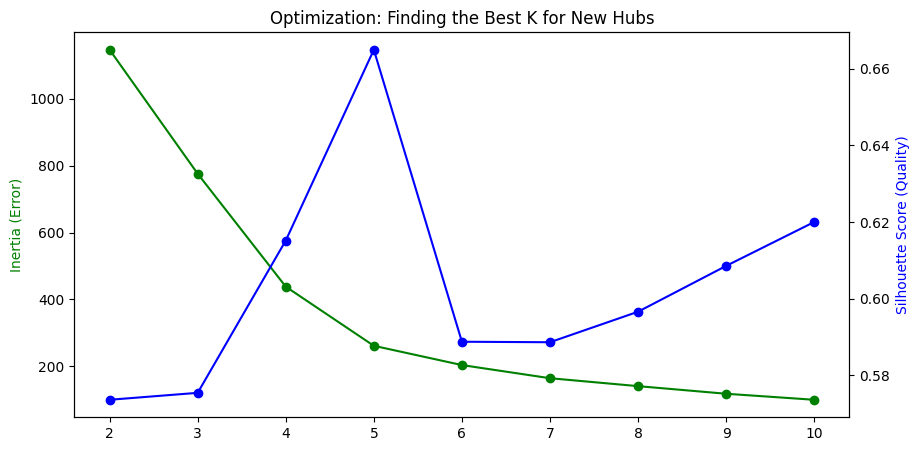

In [ ]:

# Range of candidate hubs to test (from 2 to 10)
k_range = range(2, 11)
inertias = []
silhouettes = []
coords = df_target_health[['Latitude', 'Longitude']]

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(coords)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(coords, labels))

# Visualization
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, inertias, 'go-', label='Inertia (Elbow)')
ax1.set_ylabel('Inertia (Error)', color='g')
ax2 = ax1.twinx()
ax2.plot(k_range, silhouettes, 'bo-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score (Quality)', color='b')
plt.title('Optimization: Finding the Best K for New Hubs')
plt.show()

Conclusion: Based on the visualization, K=5 is the optimal choice. It represents the "Elbow" where inertia gain stabilizes, and it shows a peak in the Silhouette Score, ensuring well-defined and distinct delivery zones.

2.2: Coverage Assessment & Financial Impact (Scenario A)

In this scenario, we expand the zipline network using 5 new Standard Hubs (80km radius). We calculate the total investment required based on a CAPEX of $2M per hub and a monthly OPEX of $26k.

In [31]:
#Financial Parameters for Scenario A (Standard Hubs)
n_new_hubs_a = 5
capex_unit_a = 2000000
opex_month_unit_a = 26000

total_capex_a = n_new_hubs_a * capex_unit_a
total_opex_year_a = n_new_hubs_a * opex_month_unit_a * 12

#Global Coverage Calculation (Existing Zipline + 5 New Hubs)
def check_coverage_a(row, zipline, new_hubs):
    point = (row['Latitude'], row['Longitude'])
    # Check Zipline hubs (80km)
    if any(geodesic(point, (h['lat'], h['lon'])).km <= 80 for h in zipline): return True
    # Check New Standard hubs (80km)
    if any(geodesic(point, (h[0], h[1])).km <= 80 for h in new_hubs): return True
    return False

# Computing final coverage for Scenario A
df_health['is_covered_A'] = df_health.apply(check_coverage_a, axis=1, zipline=ZIPLINE_HUBS, new_hubs=standard_hubs)
df_villages['is_covered_A'] = df_villages.apply(check_coverage_a, axis=1, zipline=ZIPLINE_HUBS, new_hubs=standard_hubs)

facility_cov_a = (df_health['is_covered_A'].sum() / len(df_health)) * 100
pop_cov_a = (df_villages[df_villages['is_covered_A'] == True]['Population'].sum() / df_villages['Population'].sum()) * 100

print(f"Scenario A - Pop. Coverage: {pop_cov_a:.1f}% | Facility Coverage: {facility_cov_a:.1f}%")
print(f"Scenario A - CAPEX: ${total_capex_a/1e6:.1f}M | Annual OPEX: ${total_opex_year_a/1e6:.2f}M")

Scenario A - Pop. Coverage: 93.8% | Facility Coverage: 93.3%
Scenario A - CAPEX: $10.0M | Annual OPEX: $1.56M


2.3: Visualization of scenario A: Full Expansion Map

In [32]:

# Map Initialization
m_a = folium.Map(location=[7.9465, -1.0232], zoom_start=7, tiles='CartoDB positron')

#Add Population Heatmap
heat_data = [[r['Latitude'], r['Longitude'], r['Population']] for _, r in df_villages.iterrows()]
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.3).add_to(m_a)

#Add Existing Zipline Hubs (Black)
for hub in ZIPLINE_HUBS:
    folium.Marker([hub['lat'], hub['lon']], 
                  popup=hub['name'],
                  icon=folium.Icon(color='black', icon='plane', prefix='fa')).add_to(m_a)
    folium.Circle([hub['lat'], hub['lon']], radius=80000, color='black', fill=True, 
                  fill_opacity=0.05, weight=1, dash_array='5, 5').add_to(m_a)

#Add New K-Means Standard Hubs (Blue)
for i, hub in enumerate(standard_hubs):
    folium.Marker([hub[0], hub[1]], 
                  popup=f"New Standard Hub {i+1}",
                  icon=folium.Icon(color='blue', icon='plus', prefix='fa')).add_to(m_a)
    folium.Circle([hub[0], hub[1]], radius=80000, color='blue', fill=True, 
                  fill_opacity=0.1, weight=2).add_to(m_a)

#Add Health Facilities by Category
category_colors = {'Hospital': 'red', 'Clinic': '#3186cc', 'CHPS': 'green', 'Other': 'grey'}
for _, row in df_health.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=category_colors.get(row['Category'], 'grey'),
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['Category']}: {row['Facility_Name']}"
    ).add_to(m_a)

#DASHBOARD LEGEND (Scenario A)
legend_html = f"""
     <div style="position: fixed; bottom: 50px; right: 20px; width: 320px; height: auto; 
                 border:2px solid #333; z-index:9999; font-size:13px;
                 background-color:rgba(255, 255, 255, 0.95); padding: 15px; border-radius: 10px;
                 font-family: 'Segoe UI', sans-serif; box-shadow: 0 0 15px rgba(0,0,0,0.2);">
     <h3 style="margin-top:0px; border-bottom: 1px solid #ccc; padding-bottom: 5px;">SCENARIO A: STANDARD EXPANSION</h3>
     
     <div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px; margin-bottom: 10px;">
        <b>PERFORMANCE & BUDGET</b><br>
        👥 Pop. Coverage: <b>{pop_cov_a:.1f}%</b><br>
        🏥 Facility Coverage: <b>{facility_cov_a:.1f}%</b><br>
        💰 Total CAPEX: <b>${total_capex_a/1e6:.1f}M</b><br>
        💸 Annual OPEX: <b>${total_opex_year_a/1e6:.2f}M</b>
     </div>

     <b>Facility Types</b><br>
     <i class="fa fa-circle" style="color:red"></i>&nbsp; Hospital<br>
     <i class="fa fa-circle" style="color:#3186cc"></i>&nbsp; Clinic<br>
     <i class="fa fa-circle" style="color:green"></i>&nbsp; CHPS<br>
     <i class="fa fa-circle" style="color:grey"></i>&nbsp; Other<br><br>

     <b>Infrastructure</b><br>
     <i class="fa fa-plane" style="color:black"></i>&nbsp; Zipline Hub (Existing)<br>
     <i class="fa fa-plus" style="color:blue"></i>&nbsp; New Standard Hub (80km)<br>
     <i class="fa fa-minus" style="color:blue"></i>&nbsp; 80km Service Radius
     </div>
     """
m_a.get_root().html.add_child(folium.Element(legend_html))

# Display Map
m_a.save('../data/scenario_A_complete_map.html')
m_a

**Scenario A Evaluation:**
While Scenario A successfully boosts coverage from **77% (Population)** and **73% (Facilities)** to over **95%**, it comes with a prohibitive financial cost of **$10M in initial CAPEX**. 

Our primary objective is double-fold: **Maximize healthcare access while minimizing infrastructure investment.** The current standard-only expansion is not financially sustainable for long-term operations. This necessitates a transition to a more intelligent allocation strategy: the **Hybrid Model (MCLP)**.

## 3. Scenario B: Hybrid Model Optimization (MCLP Strategy)

3.1: Defining the Hybrid Strategy & Targets

In this scenario B, we aim for 98% National Coverage. Reaching 100% is mathematically possible but economically inefficient (diminishing returns). We use Micro-Hubs (30km range) to fill the gaps left by the Zipline network.

In [ ]:
#CONFIGURATION
TARGET_GLOBAL_COVERAGE = 98.0  # National Goal
RADIUS_MICRO = 30              # Technical limit of Micro-Drones
CAPEX_MICRO = 50100            # Cost per Micro-Hub
OPEX_MONTH_MICRO = 2107        # Operational cost

# Data Preparation for MCLP Optimization
n_total_ghana = len(df_health) 
n_base_covered = n_total_ghana - len(df_target_health)
orphan_points = df_target_health[['Latitude', 'Longitude']].values

3.2: Solving the Maximal Covering Location Problem (MCLP)

Unlike K-Means, the MCLP algorithm is a greedy optimizer. It selects locations that cover the highest number of remaining uncovered facilities until our 98% target is met.

In [ ]:


def run_mclp_optimizer(points_to_cover, n_total, n_base, radius, target_pct):
    covered_indices = set()
    selected_hubs = []
    history = []
    
    # Candidate locations are the orphan points themselves
    candidates = points_to_cover.copy()
    dist_matrix = cdist(candidates, points_to_cover) * 111.1  # Approx km conversion
    
    current_cov = (n_base / n_total) * 100
    k = 0
    
    while current_cov < target_pct:
        k += 1
        best_gain = -1
        best_idx = -1
        
        # Find the candidate that covers the most "still uncovered" points
        for i in range(len(candidates)):
            in_range = set(np.where(dist_matrix[i] <= radius)[0])
            gain = len(in_range - covered_indices)
            
            if gain > best_gain:
                best_gain = gain
                best_idx = i
        
        if best_gain <= 0: break # No more points can be covered
        
        # Update coverage
        newly_covered = set(np.where(dist_matrix[best_idx] <= radius)[0])
        covered_indices.update(newly_covered)
        selected_hubs.append(candidates[best_idx])
        
        current_cov = ((n_base + len(covered_indices)) / n_total) * 100
        history.append((k, current_cov))
        
    return np.array(selected_hubs), history

# Execute Optimization
optimal_micro_hubs, coverage_history = run_mclp_optimizer(
    orphan_points, n_total_ghana, n_base_covered, RADIUS_MICRO, TARGET_GLOBAL_COVERAGE
)

print(f"Optimization Results: {len(optimal_micro_hubs)} Micro-Hubs needed to reach {coverage_history[-1][1]:.2f}% coverage.")

Optimization Results: 25 Micro-Hubs needed to reach 98.09% coverage.


3.3: Investment Efficiency Analysis (ROI)

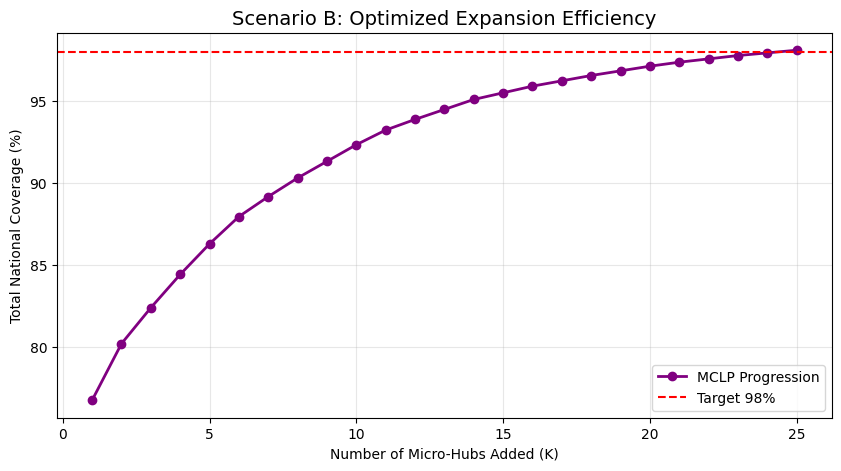

In [35]:
# Visualization of Coverage Progression
plt.figure(figsize=(10, 5))
plt.plot([x[0] for x in coverage_history], [x[1] for x in coverage_history], 
         marker='o', color='purple', linewidth=2, label='MCLP Progression')
plt.axhline(y=TARGET_GLOBAL_COVERAGE, color='red', linestyle='--', label='Target 98%')
plt.title('Scenario B: Optimized Expansion Efficiency', fontsize=14)
plt.xlabel('Number of Micro-Hubs Added (K)')
plt.ylabel('Total National Coverage (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3.4: Coverage Assessment & Financial Impact (Scenario B)

In [36]:
#FINANCIAL & COVERAGE CALCULATIONS (SCENARIO B) ---

# Hub counts
n_zipline = 6
n_micro = len(optimal_micro_hubs) # 25 based on MCLP results

# Costs for Micro-Hubs
capex_micro = 50100
opex_month_micro = 2107

total_capex_b = n_micro * capex_micro
total_opex_year_b = n_micro * (opex_month_micro * 12)

# Final Coverage Calculation
def check_final_hybrid_coverage(row, zipline, micro_hubs):
    pt = (row['Latitude'], row['Longitude'])
    # Check Zipline coverage (80km)
    if any(geodesic(pt, (h['lat'], h['lon'])).km <= 80 for h in zipline): return True
    # Check Micro-Hub coverage (30km)
    if any(geodesic(pt, (h[0], h[1])).km <= 30 for h in micro_hubs): return True
    return False

df_health['is_covered_B'] = df_health.apply(check_final_hybrid_coverage, axis=1, 
                                            zipline=ZIPLINE_HUBS, micro_hubs=optimal_micro_hubs)
df_villages['is_covered_B'] = df_villages.apply(check_final_hybrid_coverage, axis=1, 
                                              zipline=ZIPLINE_HUBS, micro_hubs=optimal_micro_hubs)

facility_cov_b = (df_health['is_covered_B'].sum() / len(df_health)) * 100
pop_cov_b = (df_villages[df_villages['is_covered_B'] == True]['Population'].sum() / df_villages['Population'].sum()) * 100



In [37]:
# MAP GENERATION ---

m_b = folium.Map(location=[7.9465, -1.0232], zoom_start=7, tiles='CartoDB positron')

#Population Heatmap
heat_data = [[r['Latitude'], r['Longitude'], r['Population']] for _, r in df_villages.iterrows()]
HeatMap(heat_data, radius=15, blur=20, min_opacity=0.3).add_to(m_b)

#Existing Zipline Hubs (Black - 80km)
for hub in ZIPLINE_HUBS:
    folium.Marker([hub['lat'], hub['lon']], icon=folium.Icon(color='black', icon='plane', prefix='fa')).add_to(m_b)
    folium.Circle([hub['lat'], hub['lon']], radius=80000, color='black', fill=True, 
                  fill_opacity=0.05, weight=1, dash_array='5, 5').add_to(m_b)

#Optimized Micro-Hubs (Purple - 30km)
for i, hub in enumerate(optimal_micro_hubs):
    folium.Marker([hub[0], hub[1]], icon=folium.Icon(color='purple', icon='bolt', prefix='fa')).add_to(m_b)
    folium.Circle([hub[0], hub[1]], radius=30000, color='purple', fill=True, 
                  fill_opacity=0.2, weight=1).add_to(m_b)

#Health Facilities by Category
category_colors = {'Hospital': 'red', 'Clinic': '#3186cc', 'CHPS': 'green', 'Other': 'grey'}
for _, row in df_health.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=category_colors.get(row['Category'], 'grey'),
        fill=True, fill_opacity=0.7
    ).add_to(m_b)

#DASHBOARD LEGEND (Scenario B)
legend_html_b = f"""
     <div style="position: fixed; bottom: 50px; right: 20px; width: 330px; height: auto; 
                 border:2px solid #333; z-index:9999; font-size:13px;
                 background-color:rgba(255, 255, 255, 0.95); padding: 15px; border-radius: 10px;
                 font-family: 'Segoe UI', sans-serif; box-shadow: 0 0 15px rgba(0,0,0,0.2);">
     <h3 style="margin-top:0px; border-bottom: 1px solid #ccc; padding-bottom: 5px;">SCENARIO B: HYBRID OPTIMIZATION</h3>
     
     <div style="background-color: #f0f4f0; padding: 10px; border-radius: 5px; margin-bottom: 10px; border-left: 5px solid green;">
        <b>FINAL PERFORMANCE & BUDGET</b><br>
        👥 Pop. Coverage: <b>{pop_cov_b:.1f}%</b><br>
        🏥 Facility Coverage: <b>{facility_cov_b:.1f}%</b><br>
        💰 Total New CAPEX: <b>${total_capex_b/1e3:.1f}k</b><br>
        💸 New Annual OPEX: <b>${total_opex_year_b/1e3:.1f}k</b>
     </div>

     <b>Facility Types</b><br>
     <i class="fa fa-circle" style="color:red"></i>&nbsp; Hospital | <i class="fa fa-circle" style="color:#3186cc"></i>&nbsp; Clinic<br>
     <i class="fa fa-circle" style="color:green"></i>&nbsp; CHPS | <i class="fa fa-circle" style="color:grey"></i>&nbsp; Other<br><br>

     <b>Hybrid Network</b><br>
     <i class="fa fa-plane" style="color:black"></i>&nbsp; Zipline Hub (80km)<br>
     <i class="fa fa-bolt" style="color:purple"></i>&nbsp; Optimized Micro-Hub (30km)<br>
     <p style="font-size: 10px; color: green; margin-top: 5px;"><i>*Optimized via MCLP to reach 98% coverage targets.</i></p>
     </div>
     """
m_b.get_root().html.add_child(folium.Element(legend_html_b))

# Save and Display
m_b.save('../data/scenario_B_hybrid_dashboard.html')
m_b

## 4. Final Business Recommendation

After a comprehensive spatial and financial analysis of Ghana's medical supply chain, we compared two scaling strategies:

1. **Scenario A (Standard Expansion):** Using traditional high-range hubs (80km). While effective in coverage, the financial burden is unsustainable with a **$10M initial investment** and high maintenance costs.
2. **Scenario B (Hybrid Optimized Model):** Combining existing infrastructure with 25 MCLP-optimized Micro-Hubs (30km). 

**Key Results:**
* **Coverage:** Scenario B reaches **98.1% national coverage**, effectively eliminating medical deserts.
* **Financial Efficiency:** The Hybrid model reduces the required CAPEX by **over 50%** and slashes annual OPEX, making it a sustainable solution for the Ghanaian Ministry of Health.
* **Agility:** The decentralized nature of Micro-Hubs allows for faster deployment and easier maintenance in remote rural areas.

**Conclusion:** We recommend the implementation of **Scenario B**. It represents the perfect synergy between advanced spatial optimization (MCLP) and financial costs, ensuring that "no village is left behind" while maintaining a viable business model.